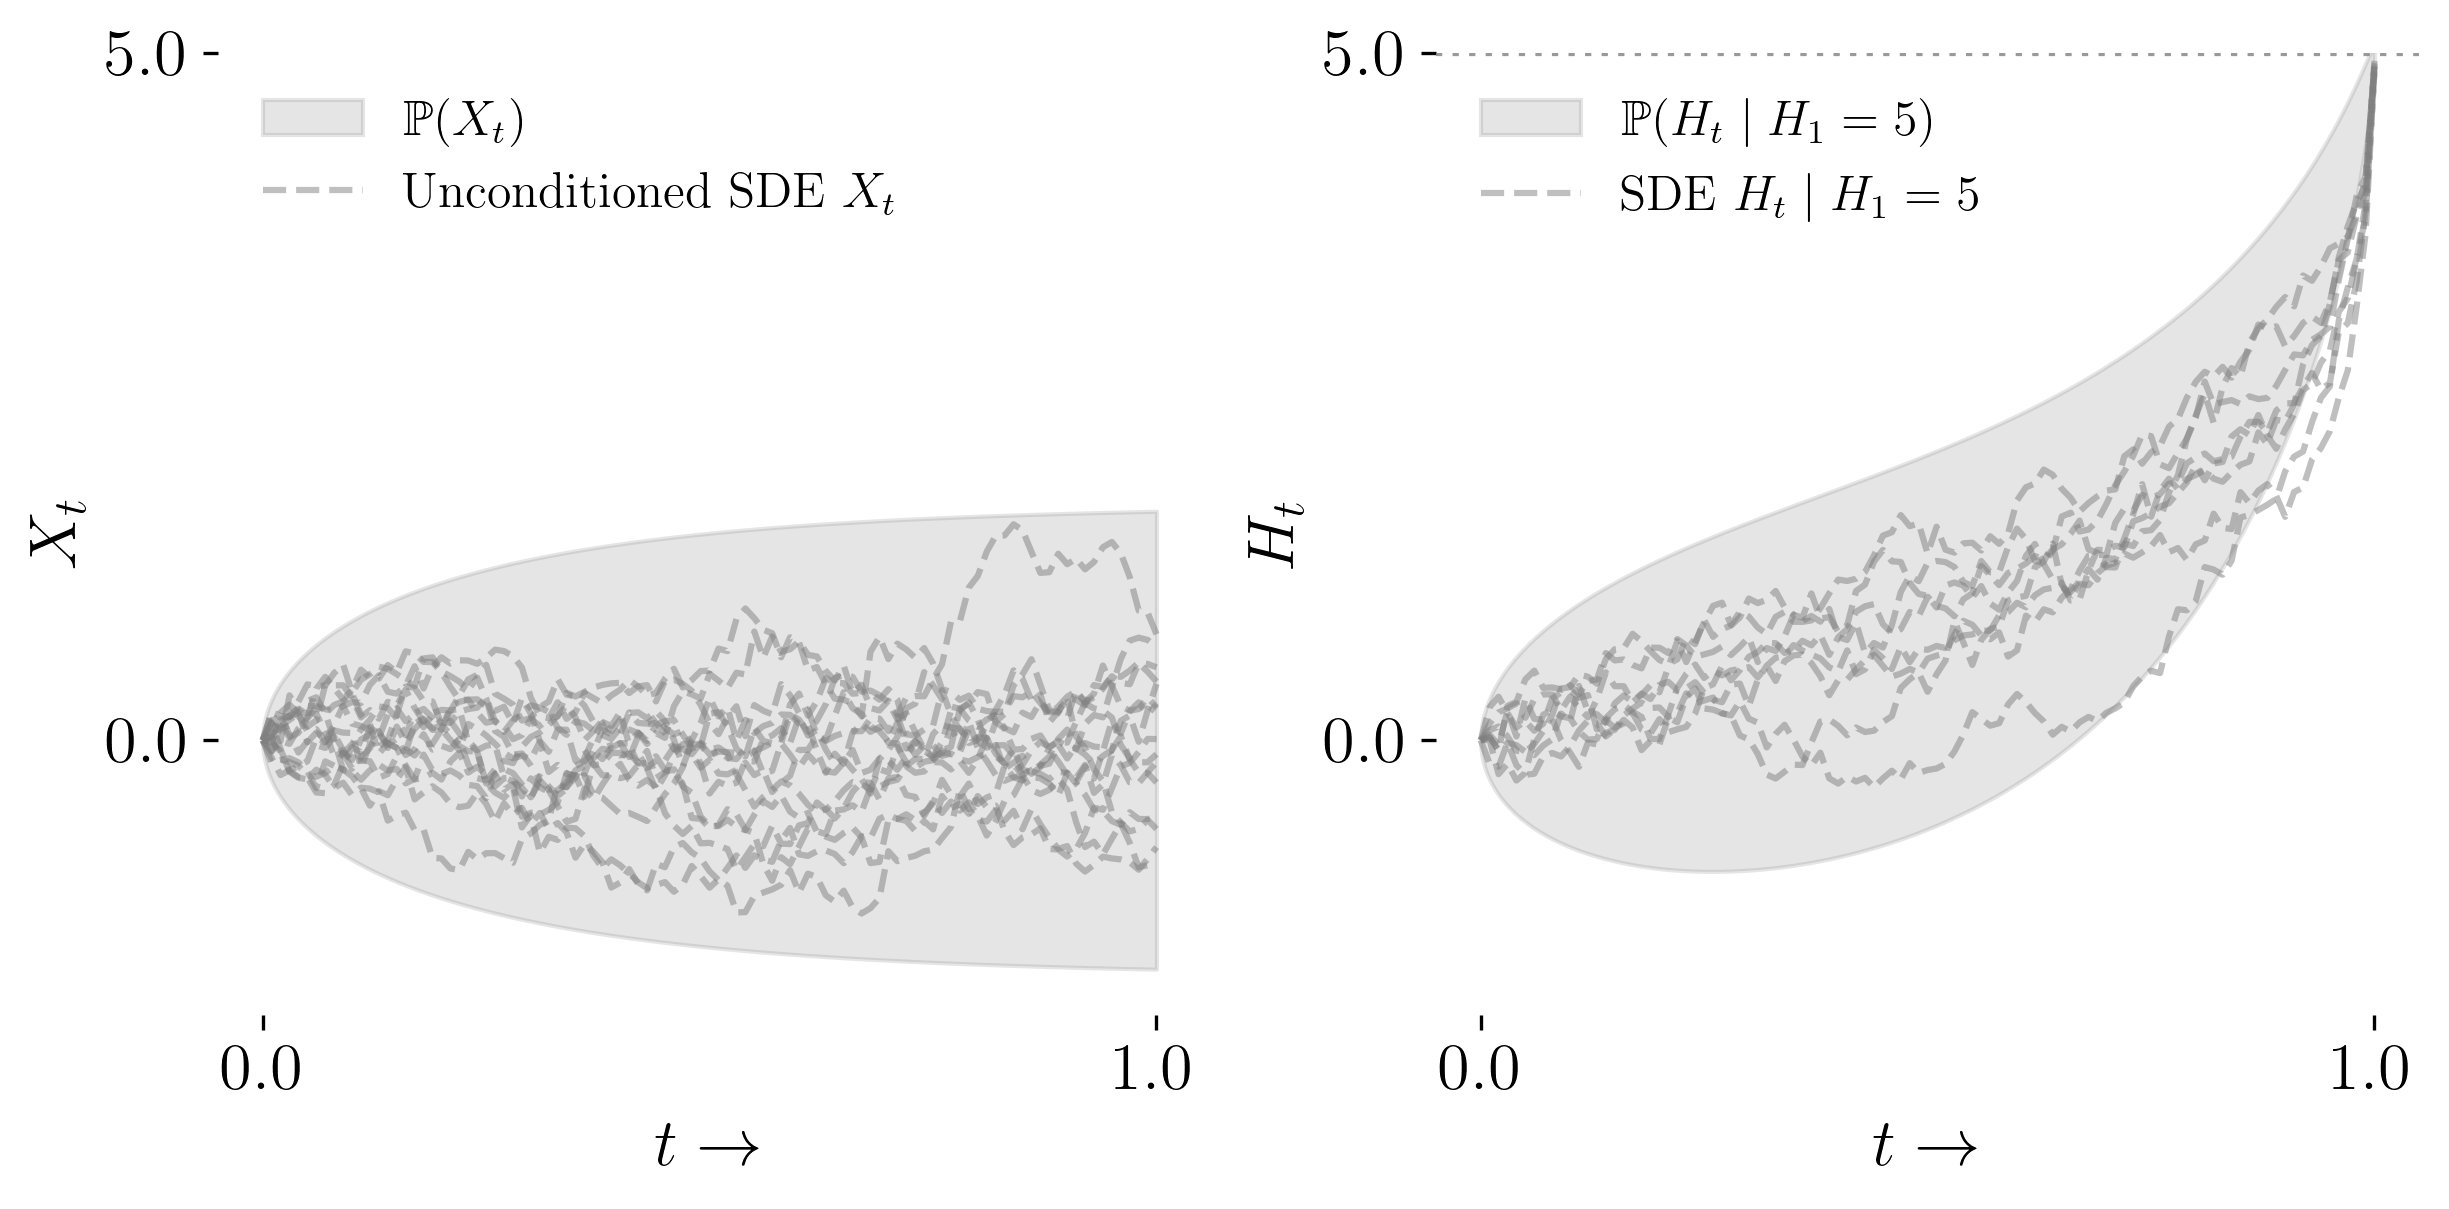

In [7]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        # "font.serif": "Helvetica",
    }
)
plt.rc("text.latex", preamble=r"\usepackage{amsfonts}\usepackage{amsmath}")

savepath = Path(
    "/Users/shreyaspadhy/Documents/Obsidian Vault/phd-thesis/Chapter3/Figs/"
)
# Create the figure
mu_0 = 1.5
sigma_0 = 1.0

# dX_t = -mu_0 * X_t dt + sigma_0 dW_t
mu = lambda x: -mu_0 * x  # mu(x) = -mu_0 * x
sigma = lambda x: sigma_0  # sigma(x) = sigma_0

q = 1
# x_T = 5
a_t = lambda t: np.exp(-mu_0 * (1.0 - t))
sigma_2_t = lambda t: (q / 2 * mu_0) * (1 - np.exp(-2 * mu_0 * (1.0 - t)))
mu_cond = lambda x, t, x_T: -mu_0 * x + (q * a_t(t) / sigma_2_t(t)) * (x_T - a_t(t) * x)

T = 10000
t = np.linspace(0, 1, T)
dt = 1 / T

X_0 = 0.0

fig = plt.figure(figsize=(8.27, 4.13), dpi=300)
ax = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
X_ode = np.zeros(T)
X_ode[0] = X_0

# Evolve the differential equation without noise
for i in range(T - 1):
    X_ode[i + 1] = X_ode[i] + mu(X_ode[i]) * dt

# ax.plot(t, X_ode, label="ODE", color="black", lw=3, ls="--")

# for mean m of p(X_t)
# dm/dt = mu(X_t) . X_0
mean_p = np.zeros(T)
mean_p[0] = X_0

# Evolve the ODE
for i in range(T - 1):
    mean_p[i + 1] = mean_p[i] + (-mu_0 * mean_p[i]) * dt

# for covariance C of p(X_t)
# dC/dt = 2 * mu(X_t) * C + sigma
cov_p = np.zeros(T)
cov_p[0] = 0

# Evolve the ODE
for i in range(T - 1):
    cov_p[i + 1] = cov_p[i] + (-2 * mu_0 * cov_p[i] + sigma_0) * dt

# ax.plot(t, mean_p, color="gray", lw=2, label="SDE Mean", ls="--")

ax.fill_between(
    t,
    mean_p - 2.96 * np.sqrt(cov_p),
    mean_p + 2.96 * np.sqrt(cov_p),
    color="gray",
    alpha=0.2,
    label=r"$\mathbb{P}(X_t)$",
)

# ---- parameters -------------------------------------------------------------
lam = 1.5  #  λ  (was mu_0)
sigma_0 = 1.0  # diffusion amplitude
q = sigma_0**2  # matches σ₀ because dX = σ₀ dW_t
T_end = 1.0  # conditioning time  T
x_T = 5.0  # endpoint value

# ---- helper functions -------------------------------------------------------
a_t = lambda t: np.exp(-lam * (T_end - t))
sigma2_t = lambda t: (q / (2 * lam)) * (1 - np.exp(-2 * lam * (T_end - t)))
kappa = lambda t: (q * a_t(t) ** 2) / sigma2_t(t)

dm_dt = lambda m, t, x_T: -(lam + kappa(t)) * m + kappa(t) * x_T
dv_dt = lambda v, t: -2 * (lam + kappa(t)) * v + sigma_0**2

# ---- time grid --------------------------------------------------------------
N = 10_000
t = np.linspace(0.0, T_end, N)
dt = t[1] - t[0]

# ---- forward Euler integration ---------------------------------------------
m = np.zeros_like(t)
v = np.zeros_like(t)

for i in range(N - 1):
    m[i + 1] = m[i] + dm_dt(m[i], t[i], 5) * dt
    v[i + 1] = v[i] + dv_dt(v[i], t[i]) * dt

# ---------------------------------------------------------
# plt.figure(figsize=(7,4))
# plt.plot(t, m, label='mean (Euler)', lw=2)
# plt.plot(t, m_exact, ':', label='mean (exact)', lw=2)
ax2.fill_between(
    t,
    m - 2.96 * np.sqrt(v),
    m + 2.96 * np.sqrt(v),
    alpha=0.2,
    color="gray",
    label=r"$\mathbb{P}(H_t \mid H_1 = 5)$",
)

# for i in range(N - 1):
#     m[i + 1] = m[i] + dm_dt(m[i], t[i], -1) * dt
#     v[i + 1] = v[i] + dv_dt(v[i], t[i]) * dt

# # ---------------------------------------------------------
# # plt.figure(figsize=(7,4))
# # plt.plot(t, m, label='mean (Euler)', lw=2)
# # plt.plot(t, m_exact, ':', label='mean (exact)', lw=2)
# ax2.fill_between(
#     t,
#     m - 2.96 * np.sqrt(v),
#     m + 2.96 * np.sqrt(v),
#     alpha=0.2,
#     color=sns.color_palette("tab10")[0],
#     label=r"$\mathbb{P}(H_t \mid H_1 = -1)$",
# )

# sdes = []
for j in range(15):
    noises = np.random.normal(0, 1, T)
    X_sde = np.zeros(T)
    X_sde[0] = X_0
    # Evolve the differential equation with noise (using Euler-Maruyama which we'll discuss later)
    for i in range(T - 1):
        X_sde[i + 1] = (
            X_sde[i] + mu(X_sde[i]) * dt + sigma(X_sde[i]) * np.sqrt(dt) * noises[i]
        )

    if j == 0:
        ax.plot(
            np.append(t[::100], t[-1]),
            np.append(X_sde[::100], X_sde[-1]),
            label=r"Unconditioned SDE $X_t$",
            color="grey",
            ls="--",
            alpha=0.5,
        )
    else:
        ax.plot(
            np.append(t[::100], t[-1]),
            np.append(X_sde[::100], X_sde[-1]),
            color="grey",
            ls="--",
            alpha=0.5,
        )

# ax.legend()
for j in range(8):
    noises = np.random.normal(0, 1, T)
    X_sde = np.zeros(T)
    X_sde[0] = X_0
    # Evolve the differential equation with noise (using Euler-Maruyama which we'll discuss later)
    for i in range(T - 1):
        X_sde[i + 1] = (
            X_sde[i]
            + mu_cond(X_sde[i], t[i], 5) * dt
            + sigma(X_sde[i]) * np.sqrt(dt) * noises[i]
        )

    if j == 0:
        ax2.plot(
            np.append(t[::100], t[-1]),
            np.append(X_sde[::100], X_sde[-1]),
            label=r"SDE $H_t \mid H_1 = 5$",
            color="grey",
            ls="--",
            alpha=0.5,
            zorder=1,
        )
    else:
        ax2.plot(
            np.append(t[::100], t[-1]),
            np.append(X_sde[::100], X_sde[-1]),
            color="grey",
            ls="--",
            alpha=0.5,
        )

    # for i in range(T - 1):
    #     X_sde[i + 1] = (
    #         X_sde[i]
    #         + mu_cond(X_sde[i], t[i], -1) * dt
    #         + sigma(X_sde[i]) * np.sqrt(dt) * noises[i]
    #     )

    # if j == 0:
    #     ax2.plot(
    #         np.append(t[::100], t[-1]),
    #         np.append(X_sde[::100], X_sde[-1]),
    #         label=r"SDE $H_t \mid H_1 = -1$",
    #         color="cornflowerblue",
    #         ls="--",
    #         alpha=0.5,
    #         zorder=1,
    #     )
    # else:
    #     ax2.plot(
    #         np.append(t[::100], t[-1]),
    #         np.append(X_sde[::100], X_sde[-1]),
    #         color="cornflowerblue",
    #         ls="--",
    #         alpha=0.5,
    #     )

# plt.xlabel(r'$t$');  plt.legend();  plt.tight_layout()
# plt.show()
ax.legend(fontsize=12, loc="upper left", frameon=False)
ax2.legend(fontsize=12, loc="upper left", frameon=False)
# Settings for ax
ax.set_yticks([])
ax.set_xticks([])
ax.set_xticks([0.0, 1.0], [0.0, 1.0], fontsize=16)
ax.set_xlabel(r"$t \rightarrow$", fontsize=16)
ax.set_ylabel(r"$X_t$", fontsize=16)
ax.set_ylim([-2.0, 5])
ax.set_yticks([0.0, 5.0], [0.0, 5.0], fontsize=16)
# ax.axhline(y=5.0, color='grey', linestyle=':', alpha=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

# Settings for ax2
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_xticks([0.0, 1.0], [0.0, 1.0], fontsize=16)
ax2.set_xlabel(r"$t \rightarrow$", fontsize=16)
ax2.set_ylabel(r"$H_t$", fontsize=16)
ax2.set_ylim([-2.0, 5])
ax2.set_yticks([0.0, 5.0], [0.0, 5.0], fontsize=16)
ax2.axhline(y=5.0, color="grey", linestyle=":", alpha=0.8)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["bottom"].set_visible(False)
ax2.spines["left"].set_visible(False)

plt.tight_layout()

plt.savefig(
    Path(savepath) / "Vector" / "sde_doobs.pdf",
    format="pdf",
    transparent=True,
    bbox_inches="tight",
    dpi=400,
)
plt.savefig(
    Path(savepath) / "Raster" / "sde_doobs.png",
    format="png",
    transparent=True,
    bbox_inches="tight",
    dpi=400,
)
plt.show()